In [3]:
source("/workspaces/estudo_de_adequabilidade_de_poder_de_teste/funcoes_final_nao_proporcionais.R")


Attaching package: ‘survival’


The following object is masked from ‘package:Rlab’:

    cancer


Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




In [ ]:
### =========================================== APLICACAO ======================= ###
n <- 300
pi <- 0.5

# Ajuste para riscos não proporcionais
distribuicao <- "weibull"

# --- GRUPO EXPERIMENTAL (A) ---
shape_falha_experimental_weibull <- 0.5
parametro_falha_experimental <- 2.0 
parametro_censura_experimental <- 10.89
shape_censura_experimental_weibull <- shape_falha_experimental_weibull

# --- GRUPO CONTROLE (B) ---
shape_falha_controle_weibull <- 2.0
parametro_falha_controle <- 4.0
parametro_censura_controle <- 6.11
shape_censura_controle_weibull <- shape_falha_controle_weibull

In [5]:
dados <- exemplo(distribuicao, n, pi, 
                    parametro_falha_experimental, parametro_falha_controle, 
                    parametro_censura_experimental, parametro_censura_controle,
                    shape_falha_experimental_weibull, shape_censura_experimental_weibull, 
                    shape_falha_controle_weibull, shape_censura_controle_weibull, 
                    sdlog_falha_experimental, sdlog_censura_experimental, 
                    sdlog_falha_controle, sdlog_censura_controle)


=== Relatório da Simulação ===
Grupo Experimental (A) - Censura Observada: 26.5%
Grupo Controle     (B) - Censura Observada: 30.2%


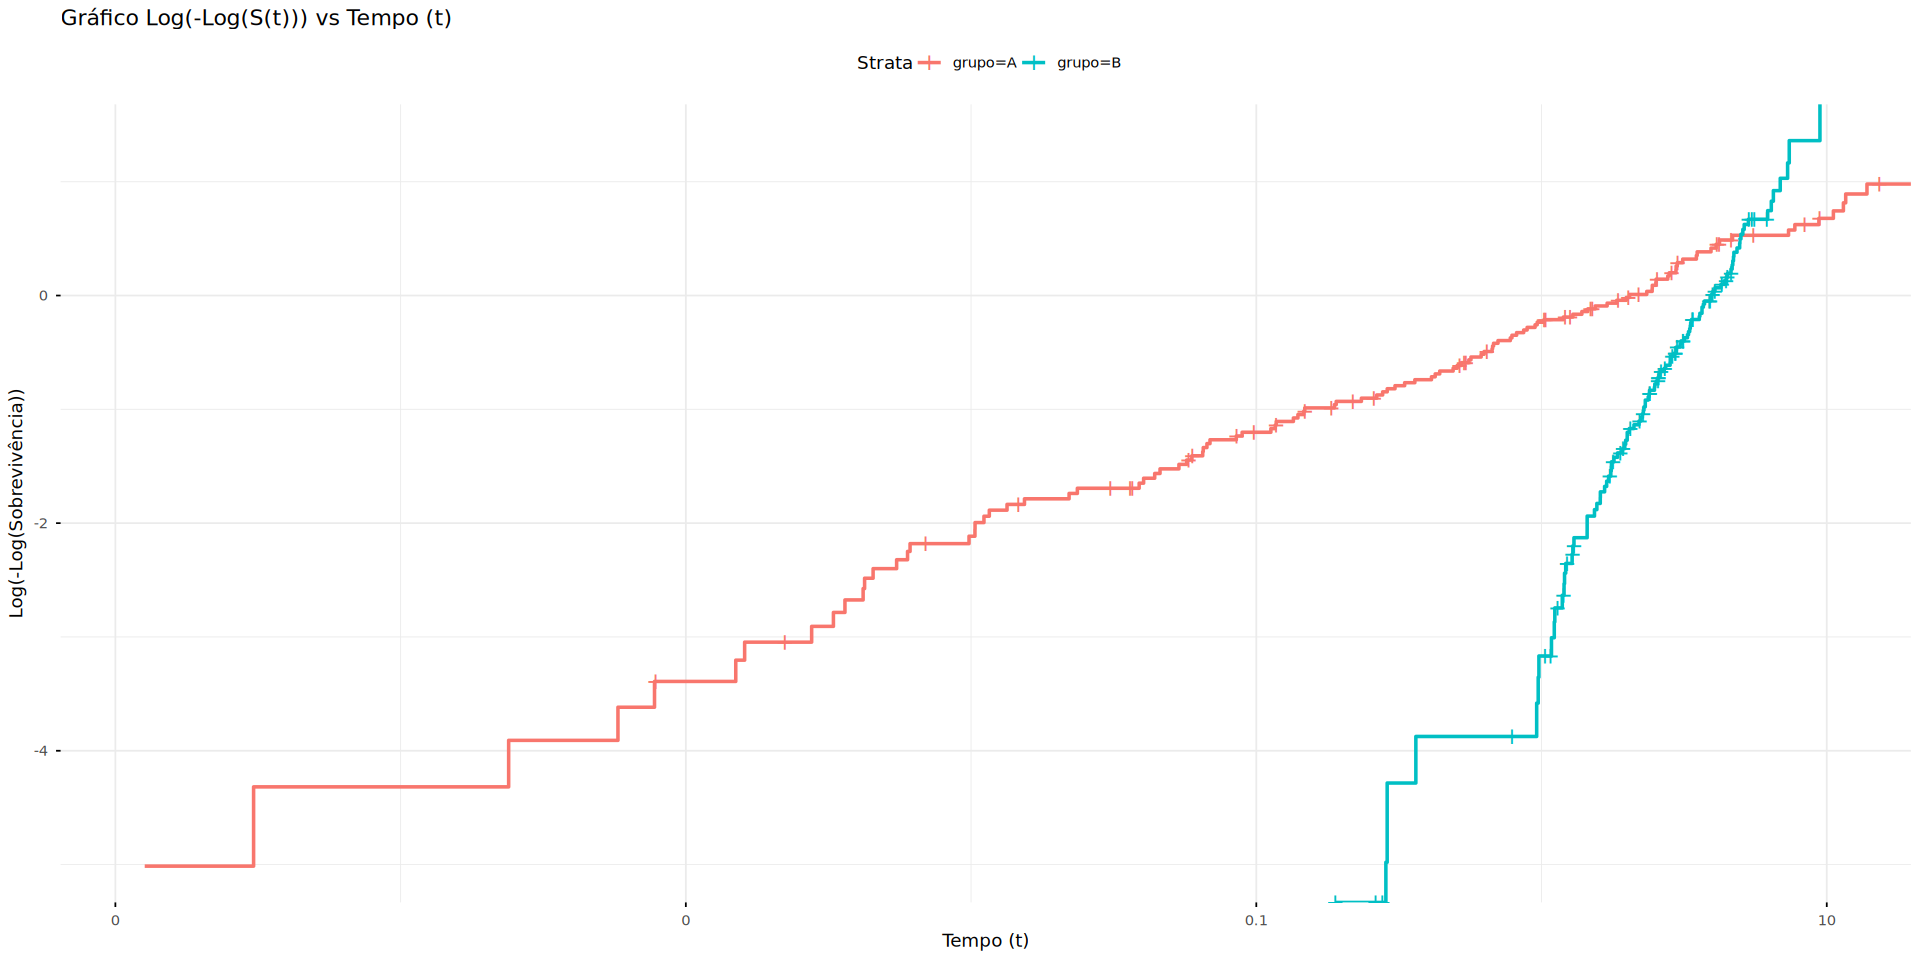

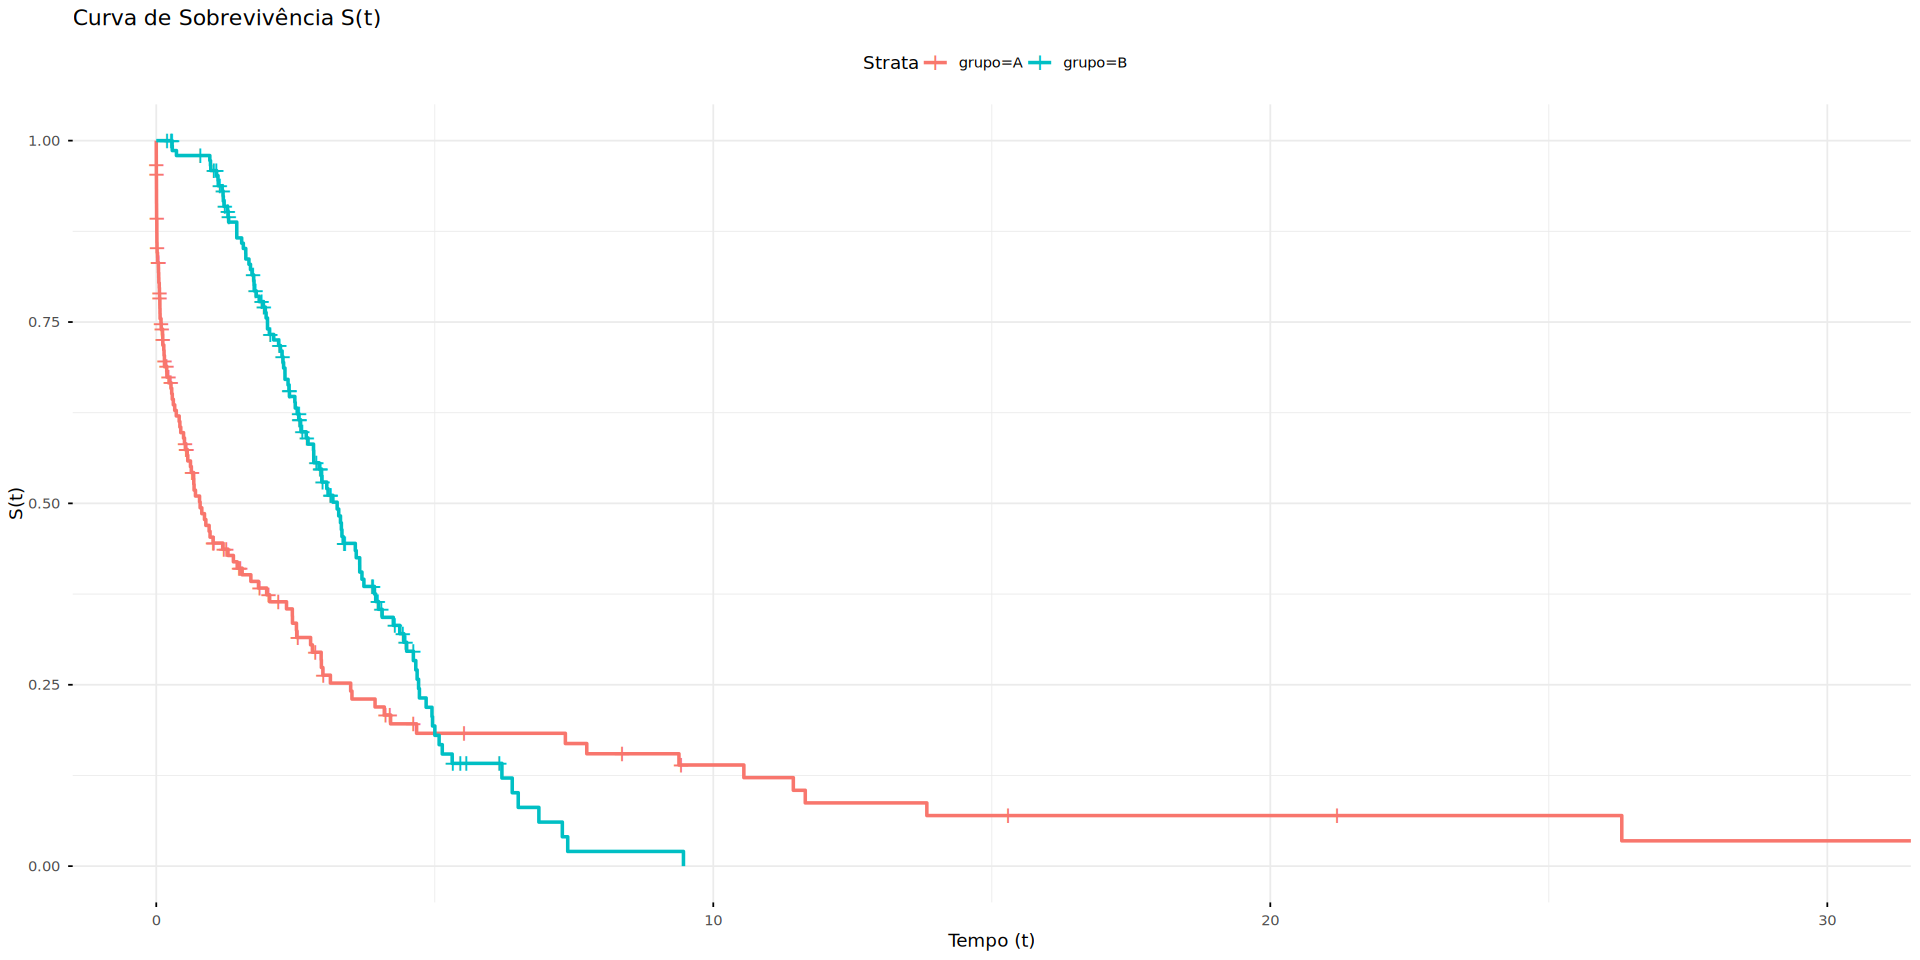

In [6]:
curva <- survfit(Surv(z, delta) ~ grupo, data = dados)
ggsurvplot(curva, 
           fun = "cloglog",   # Aplica log(-log(S(t))) no eixo Y
           # Não usamos nenhum argumento de log para o eixo X
           ggtheme = theme_minimal(),
           title = "Gráfico Log(-Log(S(t))) vs Tempo (t)",
           xlab = "Tempo (t)", 
           ylab = "Log(-Log(Sobrevivência))")

ggsurvplot(
  curva,
  conf.int = FALSE,
  risk.table = FALSE,
  ggtheme = theme_minimal(),
  title = "Curva de Sobrevivência S(t)",
  xlab = "Tempo (t)",
  ylab = "S(t)"
)$plot